In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Dataset Loaded Successfully
Rows: 307511
Columns: 122
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


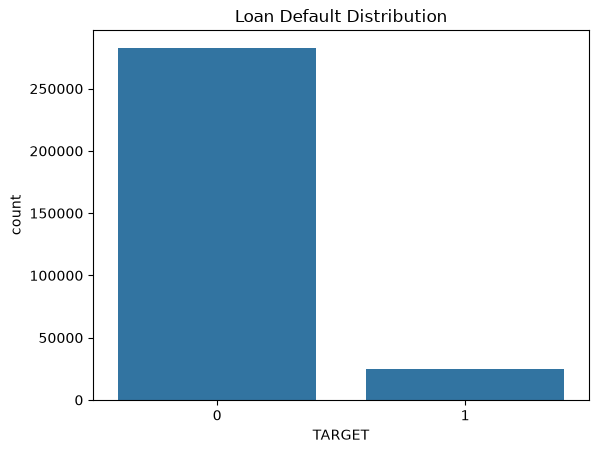

In [3]:
df = pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\data\\raw\\application_train.csv")

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()
df.info()
df.describe()
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True) * 100
sns.countplot(x="TARGET", data=df)
plt.title("Loan Default Distribution")
plt.show()

In [4]:
missing = df.isnull().sum()

missing_percent = (
    missing / len(df) * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
).head(20)

,Missing Count,Missing Percentage
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


In [5]:
important_cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE"
]

df[important_cols].head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,M,Secondary / secondary special,Working
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,F,Higher education,State servant
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,M,Secondary / secondary special,Working
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,F,Secondary / secondary special,Working
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,M,Secondary / secondary special,Working


In [6]:
df[important_cols].describe(include="all")

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE
count,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511,307511,307511
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,8
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,Secondary / secondary special,Working
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202448,218391,158774
mean,0.080729,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,-16036.995067,63815.045904,NaN,NaN,NaN
std,0.272419,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,4363.988632,141275.766519,NaN,NaN,NaN
min,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25229.000000,-17912.000000,NaN,NaN,NaN
25%,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,-19682.000000,-2760.000000,NaN,NaN,NaN
50%,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,-15750.000000,-1213.000000,NaN,NaN,NaN
75%,0.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,-12413.000000,-289.000000,NaN,NaN,NaN


In [7]:
df[important_cols].isnull().sum()

TARGET                   0
AMT_INCOME_TOTAL         0
AMT_CREDIT               0
AMT_ANNUITY             12
AMT_GOODS_PRICE        278
DAYS_BIRTH               0
DAYS_EMPLOYED            0
CODE_GENDER              0
NAME_EDUCATION_TYPE      0
NAME_INCOME_TYPE         0
dtype: int64

In [8]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

### Target Variable Analysis

The Home Credit Default Risk dataset exhibits significant class imbalance. Out of 307,511 loan applications, 282,686 (91.93%) belong to the non-default class, while only 24,825 (8.07%) belong to the default class.

This imbalance can lead to biased model predictions favoring the majority class. Therefore, techniques such as SMOTE and evaluation metrics including ROC-AUC, Recall, and F1-Score will be used to improve minority-class detection and model robustness.

In [10]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [11]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [12]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [13]:
(-df["DAYS_BIRTH"] / 365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [14]:
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [15]:
df["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [16]:
df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [20]:
target_corr = df.corr(numeric_only=True)["TARGET"].sort_values()

target_corr.head(10)


EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

In [21]:
target_corr.tail(15)

DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

In [22]:
# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features:", len(num_cols))

# Categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Features:", len(cat_cols))
print(cat_cols.tolist())

Numerical Features: 106
Categorical Features: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


C:\Users\Asus\AppData\Local\Temp\ipykernel_9464\1836993843.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns
